In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
# import geopy.distances
from tqdm import tqdm
from sklearn.decomposition import PCA
from scipy.stats import zscore, spearmanr, wilcoxon, pearsonr
import seaborn as sns
sys.path.append('../src/')
sys.path.append('../content/')
import data_utils as du
import vis_utils as vu
import sample_locations as sl
import overlap_utils as ou

LOAD_RFV = False
if LOAD_RFV:
    # clone: https://github.com/vdplasthijs/reproducible_figures
    sys.path.append('../../reproducible_figures/scripts')
    import rep_fig_vis as rfv

## Set `data_folder` and plot example:

In [3]:
## Set data folder to the parent folder with the subfolders for each modality (e.g. alphaearth, dynamicworld, tessera):
data_folder = '../data/'

# list_ids, modality_folders, gdf_points = du.get_list_complete_ids(data_folder)
# print(f'Number of samples: {len(list_ids)}')
countries = gpd.read_file('../content/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')


In [24]:
## Get different combinations of GFMs as regressors, and only geospatial modalities as targets:

n_splits = 20

sample_types = ['cropharvest', 'biomass', 'random_sample', 'lc_stratified_sample']
pca_equalize_ambient_dim = False
gfm_mods = ['alphaearth', 'tessera', 'geoclip', 'satclip']

target_list_plot = []
for i_s, sample_type in enumerate(sample_types):
    df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type=sample_type, 
                                            modalities=gfm_mods + ['bioclim', 'human_footprint'] if sample_type in ['lc_stratified_sample', 'random_sample'] else gfm_mods,
                                            zscore_embeddings=False)

    regressor_list = list(gfm_mods)
    for im1, m1 in enumerate(gfm_mods):
        for m2 in gfm_mods[im1:]:
            if m1 != m2:
                col_names[f'{m1}_{m2}'] = col_names[m1] + col_names[m2]
                regressor_list.append(f'{m1}_{m2}')
    regressor_list.append('all_gfm')  ## add all_gfm as a regressor (predefined in du.merge_modalities)

    if sample_type == 'cropharvest':
        target_list = []
        for k in col_names[sample_type]:
            col_names[k] = [k]
            target_list.append(k)
        r2_matrix, mse_matrix, dict_mse_per_point, dict_r2_per_split = ou.get_overlap_matrix(df_all=df_all, col_names=col_names, method='classification',
                                    regressor_list=regressor_list, target_list=target_list,
                                    verbose=1, kwargs_for_method={'n_splits': n_splits,
                                                                'zscore_embeddings': True})

    elif sample_type == 'biomass':
        target_list = []
        for k in col_names[sample_type]:
            col_names[k] = [k]
            target_list.append(k)
        r2_matrix, mse_matrix, dict_mse_per_point, dict_r2_per_split = ou.get_overlap_matrix(df_all=df_all, col_names=col_names, method='regression',
                                    regressor_list=regressor_list, target_list=target_list,
                                    verbose=1, kwargs_for_method={'n_splits': n_splits, 'equalize_ambient_dim': pca_equalize_ambient_dim,
                                                                    'regression_method': 'ridge', 'zscore_embeddings': True})
    elif sample_type  == 'lc_stratified_sample':
        col_names['pop_density'] = ['pop_density']
        for c in col_names['dynamicworld']:
            col_names[c]= [c]
        target_list = ['dynamicworld', 'pop_density'] + col_names['dynamicworld']
        r2_matrix, mse_matrix, dict_mse_per_point, dict_r2_per_split = ou.get_overlap_matrix(df_all=df_all, col_names=col_names, method='regression',
                                        regressor_list=regressor_list, target_list=target_list,
                                        verbose=1, kwargs_for_method={'n_splits': n_splits, 'equalize_ambient_dim': pca_equalize_ambient_dim,
                                                                        'regression_method': 'ridge', 'zscore_embeddings': True})
    elif sample_type == 'random_sample':
        col_names['pop_density'] = ['pop_density']
        col_names['meandist_road'] = ['meandist_road']
        for c in col_names['dynamicworld']:
            col_names[c]= [c]
        target_list = ['bioclim', 'meandist_road']
        r2_matrix, mse_matrix, dict_mse_per_point, dict_r2_per_split = ou.get_overlap_matrix(df_all=df_all, col_names=col_names, method='regression',
                                        regressor_list=regressor_list, target_list=target_list,
                                        verbose=1, kwargs_for_method={'n_splits': n_splits, 'equalize_ambient_dim': pca_equalize_ambient_dim,
                                                                        'regression_method': 'ridge', 'zscore_embeddings': True})

    
    if i_s == 0:
        final_r2_matrix = r2_matrix   
        final_mse_matrix = mse_matrix 
        final_dict_mse_per_point = dict_mse_per_point
        final_dict_r2_per_split = dict_r2_per_split
    else:
        final_r2_matrix = np.concatenate((final_r2_matrix, r2_matrix), axis=1)
        final_mse_matrix = np.concatenate((final_mse_matrix, mse_matrix), axis=1)
        final_dict_mse_per_point = {**final_dict_mse_per_point, **dict_mse_per_point}
        final_dict_r2_per_split = {**final_dict_r2_per_split, **dict_r2_per_split}
    target_list_plot += target_list


alphaearth 3596
tessera 3600
geoclip 3600
satclip 3600
alphaearth 4581
tessera 4571
geoclip 4585
satclip 4585
Sample random_sample has 10000 data points out of 18973.
Sample lc_stratified_sample has 10000 data points out of 18973.
alphaearth 9695
tessera 8901
geoclip 10000
satclip 10000
bioclim 9681
human_footprint 9681
Sample random_sample has 10000 data points out of 18973.
Sample lc_stratified_sample has 10000 data points out of 18973.
alphaearth 9693
tessera 8829
geoclip 10000
satclip 10000
bioclim 9665
human_footprint 9665


In [21]:
df_r2_sem = {x: [] for x in ['model', 'target', 'mean_r2', 'sem_r2']}
for k, v in final_dict_r2_per_split.items():
    model, target = k
    r2_values = v
    mean_r2 = np.mean(r2_values)
    sem_r2 = np.std(r2_values) / np.sqrt(len(r2_values))
    df_r2_sem['model'].append(model)
    df_r2_sem['target'].append(target)
    df_r2_sem['mean_r2'].append(mean_r2)
    # assert mean_r2 == final_r2_matrix[regressor_list.index(model), target_list_plot.index(target)], f'Mean R2 {mean_r2} does not match value in final_r2_matrix {final_r2_matrix[regressor_list.index(model), target_list_plot.index(target)]} for model {model} and target {target}.'
    # if mean_r2 != final_r2_matrix[regressor_list.index(model), target_list_plot.index(target)]:
    #     print(f'Mean R2 {mean_r2} does not match value in final_r2_matrix {final_r2_matrix[regressor_list.index(model), target_list_plot.index(target)]} for model {model} and target {target}.')
    df_r2_sem['sem_r2'].append(sem_r2)
df_r2_sem = pd.DataFrame(df_r2_sem)

## Change to model x target with (mean_r2, sem_r2) as values:
df_r2_sem_pivot = df_r2_sem.pivot(index='model', columns='target', values=['mean_r2', 'sem_r2'])
df_r2_sem_pivot

mean_r2                                                  \
target                  bare   bioclim biomass_center biomass_mean     built   
model                                                                          
all_gfm             0.935019  0.891949       0.366064     0.605340  0.834016   
alphaearth          0.915910  0.834700       0.499127     0.671159  0.809065   
alphaearth_geoclip  0.917611  0.866810       0.420288     0.635032  0.808888   
alphaearth_satclip  0.922291  0.868586       0.472483     0.666909  0.814736   
alphaearth_tessera  0.934926  0.855281       0.489618     0.670731  0.841097   
geoclip             0.762774  0.804037       0.114263     0.307963  0.188607   
geoclip_satclip     0.823039  0.849412       0.090943     0.324886  0.193065   
satclip             0.750474  0.749338       0.174455     0.345301  0.191141   
tessera             0.918025  0.773849       0.372694     0.522707  0.730758   
tessera_geoclip     0.918480  0.843810       0.304884     0.508025  0.722995   
tessera_satclip     0.921550  0.832213       0.361185     0.547034  0.729472   

                                                                        \
target                 crops dynamicworld flooded_vegetation     grass   
model                                                                    
all_gfm             0.751396     0.762273           0.403845  0.743544   
alphaearth          0.665046     0.711465           0.342294  0.641658   
alphaearth_geoclip  0.676226     0.714089           0.335174  0.649216   
alphaearth_satclip  0.691955     0.727324           0.360479  0.665988   
alphaearth_tessera  0.749411     0.766942           0.433454  0.744034   
geoclip             0.242504     0.299745           0.065284  0.246068   
geoclip_satclip     0.299834     0.336553           0.096126  0.310986   
satclip             0.305986     0.331272           0.128771  0.305389   
tessera             0.679591     0.705609           0.366344  0.689166   
tessera_geoclip     0.684960     0.704002           0.349114  0.692730   
tessera_satclip     0.699699     0.716176           0.377296  0.708104   

                               ...       sem_r2                               \
target             label_name  ... dynamicworld flooded_vegetation     grass   
model                          ...                                             
all_gfm              0.625419  ...     0.003508           0.008710  0.007623   
alphaearth           0.600115  ...     0.003786           0.007189  0.009075   
alphaearth_geoclip   0.634019  ...     0.003865           0.008700  0.008635   
alphaearth_satclip   0.605951  ...     0.003556           0.007301  0.008543   
alphaearth_tessera   0.575078  ...     0.003370           0.008209  0.007680   
geoclip              0.615947  ...     0.005778           0.008436  0.011567   
geoclip_satclip      0.617339  ...     0.006536           0.010225  0.014902   
satclip              0.458544  ...     0.005874           0.007475  0.012666   
tessera              0.565071  ...     0.003514           0.007497  0.008631   
tessera_geoclip      0.623195  ...     0.003928           0.009776  0.009393   
tessera_satclip      0.574801  ...     0.003459           0.007561  0.008001   

                                                                         \
target             label_name meandist_road pop_density shrub_and_scrub   
model                                                                     
all_gfm              0.006254      0.005827    0.049371        0.007461   
alphaearth           0.007578      0.005877    0.022013        0.007425   
alphaearth_geoclip   0.006569      0.006759    0.037780        0.007303   
alphaearth_satclip   0.006280      0.005074    0.025615        0.007725   
alphaearth_tessera   0.006928      0.005509    0.027112        0.006933   
geoclip              0.006821      0.007731    0.039369        0.011185   
geoclip_satclip      0.006456      0.007101    0.048726        0.01

In [22]:
model = 'alphaearth'
target = 'bioclim'

r2_values = df_r2_sem_pivot.loc[model, ('mean_r2', target)]
sem_r2 = df_r2_sem_pivot.loc[model, ('sem_r2', target)]
print(f'Model: {model}, Target: {target}, Mean R2: {r2_values:.3f}, SEM R2: {sem_r2:.3f}')

Model: alphaearth, Target: bioclim, Mean R2: 0.835, SEM R2: 0.004


R^2 for dynamicworld: alphaearth: 71.146, tessera: 70.561, alphaearth_tessera: 76.694
R^2 for biomass_mean: alphaearth: 67.116, tessera: 52.271, alphaearth_tessera: 67.073


/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_54766/1034508925.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_plot.set_xticklabels(names_plot, rotation=45, ha='right', fontsize=10)
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_54766/1034508925.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_plot.set_xticklabels(names_plot, rotation=45, ha='right', fontsize=10)


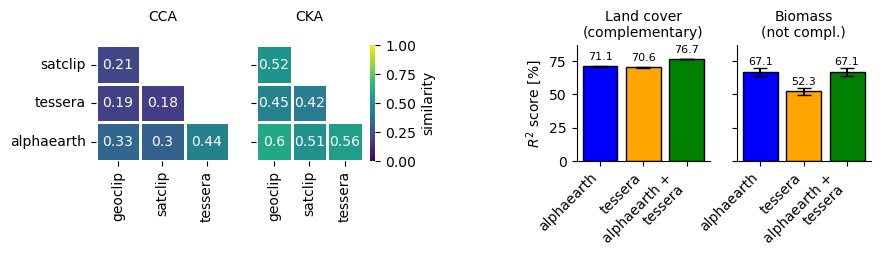

In [25]:
save_fig = True

df_sim = pd.read_csv('../outputs/task_agnostic_overlap.csv')
df_sim['model_1'] = df_sim['pair'].apply(lambda x: x.split('-')[0])
df_sim['model_2'] = df_sim['pair'].apply(lambda x: x.split('-')[1])

fig, ax = plt.subplots(1, 5, figsize=(10, 1.5), gridspec_kw={'wspace': 0.2})

dict_table_similarity = {}
for i_metric, metric in enumerate(['cca', 'cka']):
    pivot_table = df_sim.pivot(index='model_1', columns='model_2', values=metric)
    ## set row order: 
    order = ['alphaearth', 'tessera', 'satclip'][::-1]
    pivot_table = pivot_table.reindex(index=order)
    dict_table_similarity[metric] = pivot_table
    sns.heatmap(pivot_table, annot=True, vmin=0, vmax=1, cmap='viridis', 
                cbar=False if i_metric == 0 else True, rasterized=False, edgecolor='k', linewidth=1,
                cbar_kws={'label': f'similarity'}, ax=ax[i_metric]) 
    ax[i_metric].set_title(f'{metric.upper()}\n ', fontsize=10)
    ax[i_metric].set_xlabel('')
    ax[i_metric].set_ylabel('')
    if i_metric == 1:
        ax[i_metric].set_yticklabels('' for _ in ax[i_metric].get_yticklabels())

assert len(target_list_plot) == final_r2_matrix.shape[1] and len(regressor_list) == final_r2_matrix.shape[0], "Dimensions of r2_matrix do not match number of regressors and targets."

model_1, model_2 = 'alphaearth', 'tessera'
tasks_plot = ['dynamicworld', 'biomass_mean']
dict_titles = {'dynamicworld': 'Land cover\n(complementary)', 'biomass_mean': 'Biomass\n(not compl.)'}
models_plot = [model_1, model_2]
if f'{model_1}_{model_2}' in regressor_list:
    models_plot.append(f'{model_1}_{model_2}')
else:
    models_plot.append(f'{model_2}_{model_1}')  ## add the pair in the order it appears in regressor_list

ax[2].axis('off')  ## hide the third subplot (for spacing)

for i_t, t in enumerate(tasks_plot):
    idx_t = target_list_plot.index(t)
    # r2_model_1 = final_r2_matrix[regressor_list.index(model_1), idx_t] * 100
    # r2_model_2 = final_r2_matrix[regressor_list.index(model_2), idx_t] * 100
    # r2_model_pair = final_r2_matrix[regressor_list.index(f'{model_1}_{model_2}'), idx_t] * 100
    r2_model_1 = df_r2_sem_pivot.loc[model_1, ('mean_r2', t)] * 100
    r2_model_2 = df_r2_sem_pivot.loc[model_2, ('mean_r2', t)] * 100
    r2_model_pair = df_r2_sem_pivot.loc[f'{model_1}_{model_2}', ('mean_r2', t)] * 100
    sem_model_1 = df_r2_sem_pivot.loc[model_1, ('sem_r2', t)] * 100
    sem_model_2 = df_r2_sem_pivot.loc[model_2, ('sem_r2', t)] * 100 
    sem_model_pair = df_r2_sem_pivot.loc[f'{model_1}_{model_2}', ('sem_r2', t)] * 100

    print(f"R^2 for {t}: {model_1}: {r2_model_1:.3f}, {model_2}: {r2_model_2:.3f}, {model_1}_{model_2}: {r2_model_pair:.3f}")

    ## bar plot:
    ax_plot = ax[i_t + 3]
    names_plot = [x.replace('_', ' +\n') for x in models_plot]
    ax_plot.bar(names_plot, [r2_model_1, r2_model_2, r2_model_pair], 
                yerr=[sem_model_1, sem_model_2, sem_model_pair], capsize=5,
                color=['blue', 'orange', 'green'], edgecolor='black')
    for i, v in enumerate([r2_model_1, r2_model_2, r2_model_pair]):
        ax_plot.text(i, v + 5, f"{v:.1f}", ha='center', fontsize=8)
    ax_plot.set_ylim(0, 87)
    ax_plot.set_title(f'{dict_titles.get(t, t)}', fontsize=10)
    for sp in ['top', 'right']:
        ax_plot.spines[sp].set_visible(False)
    if i_t == 0:
        ax_plot.set_ylabel('$R^2$ score [%]', fontsize=10)
    else:
        ax_plot.set_yticklabels('')
    ax_plot.set_xticklabels(names_plot, rotation=45, ha='right', fontsize=10)

if LOAD_RFV:
    rfv.add_panel_label(fig=fig, ax=ax[0], label_letter='a', x_offset=0.08, y_offset=0.18, fontsize=12)
    rfv.add_panel_label(fig=fig, ax=ax[3], label_letter='b', x_offset=-0.04, y_offset=0.18, fontsize=12)

if save_fig:
    fig_folder = '../figs/'
    assert os.path.exists(fig_folder) and os.path.isdir(fig_folder), f"Figure folder {fig_folder} does not exist and/or is not a directory."
    fname = f'overlap_heatmap_and_barplots.pdf'
    plt.savefig(os.path.join(fig_folder, fname), bbox_inches='tight')


In [8]:
## test diff between cca and cka similarities across all pairs (non nan values):
inds = ~np.isnan(dict_table_similarity['cca'].values)
from scipy.stats import ttest_rel
t_statistic, p_value = ttest_rel(dict_table_similarity['cca'].values[inds], dict_table_similarity['cka'].values[inds], alternative='less')
print(f"t-statistic: {t_statistic:.3f}, p-value: {p_value:.6f}")


t-statistic: -8.883, p-value: 0.000150


In [9]:
from scipy.stats import wilcoxon 

print(wilcoxon(final_dict_r2_per_split[('alphaearth', 'dynamicworld')], final_dict_r2_per_split[('alphaearth_tessera', 'dynamicworld')], alternative='less'))
print(wilcoxon(final_dict_r2_per_split[('alphaearth', 'biomass_mean')], final_dict_r2_per_split[('alphaearth_tessera', 'biomass_mean')], alternative='less'))

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(9.5367431640625e-07))
WilcoxonResult(statistic=np.float64(110.0), pvalue=np.float64(0.5795888900756836))


In [14]:
## Create latex table for the R^2 scores:
def cap_first_letter(s):
    if len(s) > 0:
        return s[0].upper() + s[1:]
    else:
        return s

dict_regressor_list_plot = {r: 'All GFMs' if r == 'all_gfm' else r.replace('_', ' + ') for r in regressor_list}
save_table = True

plot_table = 'lc_classes'  ## options: 'main_tasks', 'lc_classes'
metric_score = 'r2'

if metric_score == 'mse':
    name_score_reg = 'MSE'
    name_score_class = 'MSE'
elif metric_score == 'r2':
    name_score_reg = r"$R^2$ [\%]"
    name_score_class = r"accuracy [\%]"
if plot_table == 'main_tasks':
    dict_task_names = {'label_name': 'Crops', 'biomass_mean': 'Biomass',
                    'dynamicworld': 'Land cover', 'bioclim': 'Bioclimatic', 
                    'pop_density': 'Pop.', 'meandist_road': 'Dist. road',
                    }
    # dict_task_names = {'biomass_mean': 'Biomass (mean)', 'biomass_center': 'Biomass (centre-pixel)'}
    caption = r"\textbf{Fused embeddings typically outperform single embeddings, and the best combination is task-dependent}. " + name_score_reg + r" scores for regression tasks (ridge regression), " + name_score_class + r" for the classification task (logistic regression). Best score for each task is highlighted in bold (mean $\pm$ SEM), for single-embedding, multi-embedding and all embeddings (if better than previous)." 

elif plot_table == 'lc_classes':
    dict_task_names = {
        **{k: r"\textit{" + cap_first_letter(k.split('_')[0]).replace('Flooded', 'Flood.') + '}' for k in col_names['dynamicworld']}
                        }
    caption = r"\textbf{Class-specific scores for land cover regression}. " + name_score_reg + r" scores per class (ridge regression). Best score for each task is highlighted in bold (mean $\pm$ SEM), for single-embedding, multi-embedding and all embeddings (if better than previous)." 

task_names_plot = [dict_task_names[t] if t in dict_task_names else t for t in target_list_plot]

dict_df_tmp = {}
for metric_table in ['mean_r2', 'sem_r2']:
    df_tmp = df_r2_sem_pivot[metric_table]
    df_tmp = df_tmp.rename(index=dict_regressor_list_plot, columns=dict_task_names)
    df_tmp = df_tmp.drop(columns=[c for c in df_tmp.columns if c not in dict_task_names.values()])
    if plot_table == 'main_tasks':
        order_cols = ['Crops', 'Biomass', 'Land cover', 'Bioclimatic', 'Pop.', 'Dist. road']
    else:
        order_cols = [dict_task_names[c] for c in col_names['dynamicworld']]
    df_tmp = df_tmp[order_cols]
    order_index = ['alphaearth', 'tessera', 'geoclip', 'satclip',
        'alphaearth + tessera', 'alphaearth + geoclip',
        'alphaearth + satclip', 'tessera + geoclip', 'tessera + satclip',
        'geoclip + satclip', 'All GFMs']
    assert all(idx in df_tmp.index for idx in order_index), "Not all indices in order_index are present in df_tmp index."
    df_tmp = df_tmp.reindex(order_index)
    df_tmp.index.name = None
    df_tmp = df_tmp.reset_index()
    df_tmp = df_tmp.rename(columns={'index': 'Embeddings'})
    df_tmp.columns.name = None
    df_tmp = df_tmp.set_index('Embeddings')
    df_tmp.index.name = None
    dict_df_tmp[metric_table] = df_tmp
df_scores = dict_df_tmp['mean_r2']
df_scores_sem = dict_df_tmp['sem_r2']

if save_table:
    df_scores.to_csv(f'../outputs/r2_scores_{plot_table}.csv')

tmp = vu.create_printable_table(df_scores, df_scores_sem, save_table=save_table, filename=f'{metric_score}_scores_{plot_table}.tex', 
                          caption_tex=caption, label_tex=f'tab:{metric_score}_scores_{plot_table}', position_tex='ht',
                         cols_drop=[], folder_save='../tables/',
                         add_units=False, metric_type='min_val' if metric_score == 'mse' else 'percentage', 
                         rescale=False if metric_score == 'mse' else True,
                         highlight_best_row=True)
tmp[1]

,Embeddings,\textit{Water},\textit{Trees},\textit{Grass},\textit{Flood.},\textit{Crops},\textit{Shrub},\textit{Built},\textit{Bare},\textit{Snow}
0,alphaearth,\textbf{90.7 ± 0.4},\textbf{70.6 ± 0.7},64.2 ± 0.9,34.2 ± 0.7,66.5 ± 0.6,54.9 ± 0.7,\textbf{80.9 ± 0.6},91.6 ± 0.4,86.0 ± 0.5
1,tessera,85.5 ± 0.8,66.5 ± 0.9,\textbf{68.9 ± 0.9},\textbf{36.6 ± 0.7},\textbf{68.0 ± 0.6},\textbf{55.9 ± 0.7},73.1 ± 0.6,\textbf{91.8 ± 0.4},\textbf{87.9 ± 0.5}
2,geoclip,3.5 ± 1.6,13.7 ± 0.8,24.6 ± 1.2,6.5 ± 0.8,24.3 ± 1.0,16.9 ± 1.1,18.9 ± 1.0,76.3 ± 1.2,83.1 ± 0.7
3,satclip,7.6 ± 1.4,17.8 ± 1.0,30.5 ± 1.3,12.9 ± 0.7,30.6 ± 1.0,22.4 ± 1.3,19.1 ± 1.0,75.0 ± 1.0,80.1 ± 0.7
4,alphaearth + tessera,\textbf{92.3 ± 0.4},\textbf{74.9 ± 0.7},\textbf{74.4 ± 0.8},\textbf{43.3 ± 0.8},\textbf{74.9 ± 0.5},\textbf{63.1 ± 0.7},\textbf{84.1 ± 0.5},\textbf{93.5 ± 0.4},\textbf{89.0 ± 0.4}
5,alphaearth + geoclip,90.6 ± 0.4,70.0 ± 0.7,64.9 ± 0.9,33.5 ± 0.9,67.6 ± 0.6,55.0 ± 0.7,80.9 ± 0.6,91.8 ± 0.4,87.3 ± 0.5
6,alphaearth + satclip,91.1 ± 0.4,71.5 ± 0.7,66.6 ± 0.9,36.0 ± 0.7,69.2 ± 0.5,57.8 ± 0.8,81.5 ± 0.6,92.2 ± 0.4,87.7 ± 0.5
7,tessera + geoclip,85.1 ± 0.8,65.8 ± 0.9,69.3 ± 0.9,34.9 ± 1.0,68.5 ± 0.6,55.9 ± 0.8,72.3 ± 0.6,91.8 ± 0.4,88.7 ± 0.4
8,tessera + satclip,85.7 ± 0.8,67.1 ± 0.9,70.8 ± 0.8,37.7 ± 0.8,70.0 ± 0.6,58.1 ± 0.7,72.9 ± 0.6,92.2 ± 0.4,89.0 ± 0.4
9,geoclip + satclip,5.6 ± 2.0,16.1 ± 1.1,31.1 ± 1.5,9.6 ± 1.0,30.0 ± 1.1,21.5 ± 1.4,19.3 ± 1.1,82.3 ± 1.0,84.9 ± 0.7


In [15]:
df_compl, df_compl_and_model = ou.calculate_complementarity(df_scores=df_scores, metric_type=metric_score, aggr=None)
if plot_table == 'main_tasks':
    caption = r"\textbf{Complementarity of embeddings for downstream tasks}. Complementarity was calculated from $R^2$ scores for the regression tasks and accuracy for the classification task. Positive values are highlighted in bold and indicate positive complementarity.  ***: $p < 0.001$; **: $p < 0.01$; *: $p < 0.05$."
elif plot_table == 'lc_classes':
    caption = r"\textbf{Complementarity of embeddings for land cover regression}. Complementarity was calculated from $R^2$ scores (ridge regression). Positive values are highlighted in bold and indicate positive complementarity.  ***: $p < 0.001$; **: $p < 0.01$; *: $p < 0.05$."

df_pvals = ou.calculate_significance_table(final_dict_r2_per_split, plot_table=plot_table, verbose=0) 
save_table = True

if save_table:
    df_compl.to_csv(f'../outputs/complementarity_{plot_table}.csv')

tmp = vu.create_printable_table(df_compl, df_sem=None, df_pvals=df_pvals[1],
                                save_table=save_table, filename=f'compl_{metric_score}_scores_{plot_table}.tex', 
                          caption_tex=caption, label_tex=f'tab:compl_{metric_score}_scores_{plot_table}', position_tex='ht',
                         cols_drop=[], folder_save='../tables/',
                         add_units=False, metric_type='max_val' if metric_score == 'r2' else 'min_val', 
                         rescale=False, highlight_best_row=False, highlight_all_positive_values=True)

tmp[1]

,Embeddings,\textit{Water},\textit{Trees},\textit{Grass},\textit{Flood.},\textit{Crops},\textit{Shrub},\textit{Built},\textit{Bare},\textit{Snow}
0,alphaearth + tessera,\textbf{0.17***},\textbf{0.15***},\textbf{0.18***},\textbf{0.11***},\textbf{0.22***},\textbf{0.16***},\textbf{0.17***},\textbf{0.21***},\textbf{0.09***}
1,alphaearth + geoclip,-0.01,-0.02,\textbf{0.02*},-0.01,\textbf{0.03**},0.00,0.00,\textbf{0.02*},\textbf{0.10***}
2,alphaearth + satclip,\textbf{0.04***},\textbf{0.03***},\textbf{0.07***},\textbf{0.03**},\textbf{0.08***},\textbf{0.06***},\textbf{0.03***},\textbf{0.08***},\textbf{0.13***}
3,tessera + geoclip,-0.03,-0.02,0.01,-0.03,0.02,0.00,-0.03,0.01,\textbf{0.07***}
4,tessera + satclip,0.01,\textbf{0.02**},\textbf{0.06***},\textbf{0.02*},\textbf{0.06***},\textbf{0.05***},0.00,\textbf{0.04***},\textbf{0.09***}
5,geoclip + satclip,-0.02,-0.02,0.01,-0.04,-0.01,-0.01,0.00,\textbf{0.25***},\textbf{0.10***}
6,All GFMs,\textbf{0.13***},\textbf{0.11***},\textbf{0.17***},\textbf{0.06***},\textbf{0.22***},\textbf{0.15***},\textbf{0.13***},\textbf{0.21***},\textbf{0.16***}


## MSE per point

In [18]:
## Get different combinations of GFMs as regressors, and only geospatial modalities as targets:

n_splits = 20

sample_type = 'lc_stratified_sample'  ## options: 'cropharvest', 'biomass', 'random_sample', 'lc_stratified_sample'
target_list = ['dynamicworld']  
pca_equalize_ambient_dim = False

gfm_mods = ['alphaearth', 'tessera']
ind_best_single_model = 0

df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type=sample_type, 
                                        zscore_embeddings=False, modalities=gfm_mods + ['bioclim', 'human_footprint'] if sample_type in ['lc_stratified_sample', 'random_sample'] else gfm_mods)

regressor_list = list(gfm_mods)
## Add each pair of GFMs as a regressor:
for im1, m1 in enumerate(gfm_mods):
    for m2 in gfm_mods[im1:]:
        if m1 != m2:
            col_names[f'{m1}_{m2}'] = col_names[m1] + col_names[m2]
            regressor_list.append(f'{m1}_{m2}')
if sample_type in ['lc_stratified_sample', 'random_sample']:
    col_names['pop_density'] = ['pop_density']
    col_names['meandist_road'] = ['meandist_road']
    for c in col_names['dynamicworld']:
        col_names[c]= [c]
elif sample_type == 'biomass':
    for c in col_names['biomass']:
        col_names[c] = [c]
# regressor_list.append('all_gfm')  ## add all_gfm as a regressor (predefined in du.merge_modalities)

df_mse = {}
for target in target_list:
    for r in regressor_list:
        if sample_type == 'cropharvest':
            tmp = ou.get_accuracy_classification(df_all=df_all, col_names=col_names, regressor=r, target=target,
                                                n_splits=n_splits, zscore_embeddings=True)
        else:
            tmp = ou.get_r2_regression(df_all=df_all, col_names=col_names, regressor=r, target=target, 
                                n_splits=n_splits, equalize_ambient_dim=pca_equalize_ambient_dim,
                                regression_method='ridge', zscore_embeddings=True)
        df_mse[f'mse__{r}__{target}'] = tmp[3]['mse_per_point']
    df_mse = pd.DataFrame(df_mse)
    name_compl_col = f'compl__{regressor_list[0]}_{regressor_list[1]}__{target}'
    df_mse[name_compl_col] = (df_mse[f'mse__{regressor_list[0]}_{regressor_list[1]}__{target}'] - df_mse[f'mse__{regressor_list[ind_best_single_model]}__{target}']) / (-1 * df_mse[f'mse__{regressor_list[ind_best_single_model]}__{target}'])
    print(f'{target} Correlation of Complementarity with best model performance: {spearmanr(df_mse[f"compl__{regressor_list[0]}_{regressor_list[1]}__{target}"], df_mse[f"mse__{regressor_list[ind_best_single_model]}__{target}"])}')
    print(f'{target} Correlation of Complementarity with worse model performance: {spearmanr(df_mse[f"compl__{regressor_list[0]}_{regressor_list[1]}__{target}"], df_mse[f"mse__{regressor_list[1 - ind_best_single_model]}__{target}"])}')
    print(f'{target} Correlation of Complementarity with joint model performance: {spearmanr(df_mse[f"compl__{regressor_list[0]}_{regressor_list[1]}__{target}"], df_mse[f"mse__{regressor_list[0]}_{regressor_list[1]}__{target}"])}')
    print(f'{target} Correlation of best model performance with worse model performance: {pearsonr(df_mse[f"mse__{regressor_list[ind_best_single_model]}__{target}"], df_mse[f"mse__{regressor_list[1 - ind_best_single_model]}__{target}"])}')
    assert df_mse[f'mse__{gfm_mods[ind_best_single_model]}__{target}'].sum() < df_mse[f'mse__{gfm_mods[1 - ind_best_single_model]}__{target}'].sum(), "The chosen best single model does not have the lowest MSE, please check the MSE values and update ind_best_single_model accordingly."
    if df_mse[f'mse__{regressor_list[0]}_{regressor_list[1]}__{target}'].sum() >= df_mse[f'mse__{regressor_list[ind_best_single_model]}__{target}'].sum():
        print("The combination of models does not have a lower MSE than the best single model, please check the MSE values.")

if len(target_list) > 1:  # remove individual target columns if there are multiple targets, to avoid confusion with the complementarity column
    cols_compl = [f'compl__{regressor_list[0]}_{regressor_list[1]}__{t}' for t in target_list]
    df_mse[f'compl__{regressor_list[0]}_{regressor_list[1]}__mean'] = df_mse[cols_compl].mean(axis=1)

for c in ['id', 'lat', 'lon']:
    df_mse[c] = df_all[c]
if target_list[0] == 'dynamicworld':
    gdf_mse_dynamicworld = gpd.GeoDataFrame(df_mse, geometry=gpd.points_from_xy(df_mse.lon, df_mse.lat), crs='EPSG:4326')
elif target_list[0] == 'bioclim':
    gdf_mse_bioclim = gpd.GeoDataFrame(df_mse, geometry=gpd.points_from_xy(df_mse.lon, df_mse.lat), crs='EPSG:4326')
gdf_mse = gpd.GeoDataFrame(df_mse, geometry=gpd.points_from_xy(df_mse.lon, df_mse.lat), crs='EPSG:4326')


Sample random_sample has 10000 data points out of 18973.
Sample lc_stratified_sample has 10000 data points out of 18973.
alphaearth 9693
tessera 8829
bioclim 9665
human_footprint 9665
dynamicworld Correlation of Complementarity with best model performance: SignificanceResult(statistic=np.float64(0.2797710672115012), pvalue=np.float64(1.8043672245031052e-158))
dynamicworld Correlation of Complementarity with worse model performance: SignificanceResult(statistic=np.float64(-0.26702282063336524), pvalue=np.float64(5.21992261869378e-144))
dynamicworld Correlation of Complementarity with joint model performance: SignificanceResult(statistic=np.float64(-0.23690156321236372), pvalue=np.float64(6.983641611157122e-113))
dynamicworld Correlation of best model performance with worse model performance: PearsonRResult(statistic=np.float64(0.8572498099663535), pvalue=np.float64(0.0))


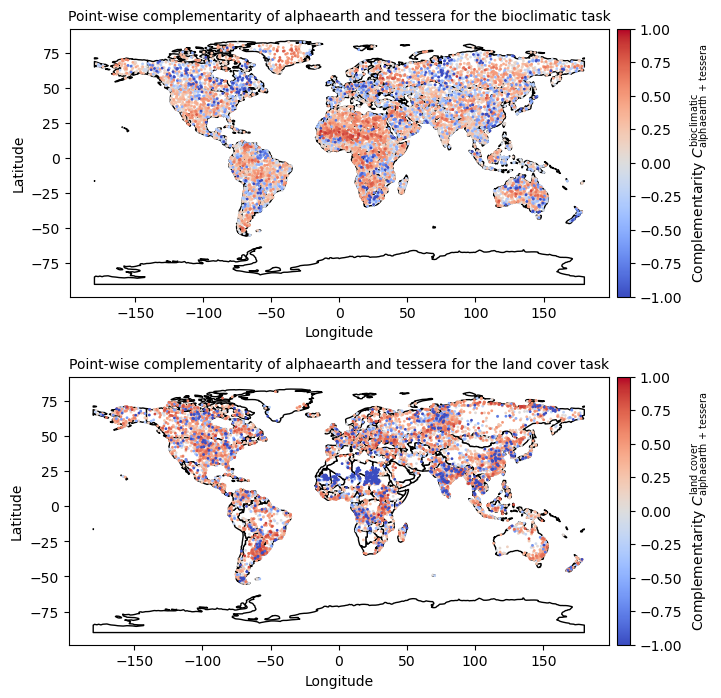

In [19]:
save_fig = True

fig, ax = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.3})

for i_target, target in enumerate(['bioclim', 'dynamicworld']):
     ax_map = ax[i_target]
     countries.plot(ax=ax_map, color="#FFFFFF", edgecolor='black')
     if target == 'bioclim':
          gdf_mse_plot = gdf_mse_bioclim 
     elif target == 'dynamicworld':
          gdf_mse_plot = gdf_mse_dynamicworld
     name_compl_col = f'compl__{regressor_list[0]}_{regressor_list[1]}__{target}'
     name_compl_col_plot = f'compl__{regressor_list[0]}_{regressor_list[1]}__mean' if len(target_list) > 1 else name_compl_col

     gdf_mse_plot['compl_abs'] = np.abs(gdf_mse_plot[name_compl_col_plot])
     gdf_mse_plot = gdf_mse_plot.sort_values('compl_abs', ascending=True)

     dict_task_names = {'label_name': 'crops', 'biomass_mean': 'biomass',
                         'dynamicworld': 'land cover', 'bioclim': 'bioclimatic', 
                         'pop_density': 'population density', 'meandist_road': 'distance to road',
                         }

     gdf_mse_plot.plot(column=name_compl_col_plot, cmap='coolwarm', legend=True, 
                    markersize=1, ax=ax_map, vmax=1, vmin=-1, legend_kwds={
                    'label': 'Complementarity ' + r"$C_\text{" + gfm_mods[0] + " + " + gfm_mods[1] + r"}^\text{" + dict_task_names[target] + "}$", 
                    'pad': 0.01, 'shrink': 1, 'fraction': 0.02},
               alpha=1)

     ax_map.set_xlabel('Longitude')
     ax_map.set_ylabel('Latitude')
     ax_map.set_title(f'Point-wise complementarity of {regressor_list[0]} and {regressor_list[1]} for the {dict_task_names[target]} task',
                    fontsize=10)



if save_fig:
     fig_folder = '../figs/'
     assert os.path.exists(fig_folder) and os.path.isdir(fig_folder), f"Figure folder {fig_folder} does not exist and/or is not a directory."
     fig.savefig(os.path.join(fig_folder, f'complementarity_map_{regressor_list[0]}_{regressor_list[1]}_multiple.pdf'), bbox_inches='tight')   

## Spatial variability of predictability and dimensionality:

Sample random_sample has 10000 data points out of 18973.
Sample lc_stratified_sample has 10000 data points out of 18973.
alphaearth 9695
tessera 8901
satclip 10000
geoclip 10000
bioclim 9681
human_footprint 9681


Text(0.5, 1.0, 'MSE of linear regression from geoclip to alphaearth\nrandom_sample sample, n_splits=3')

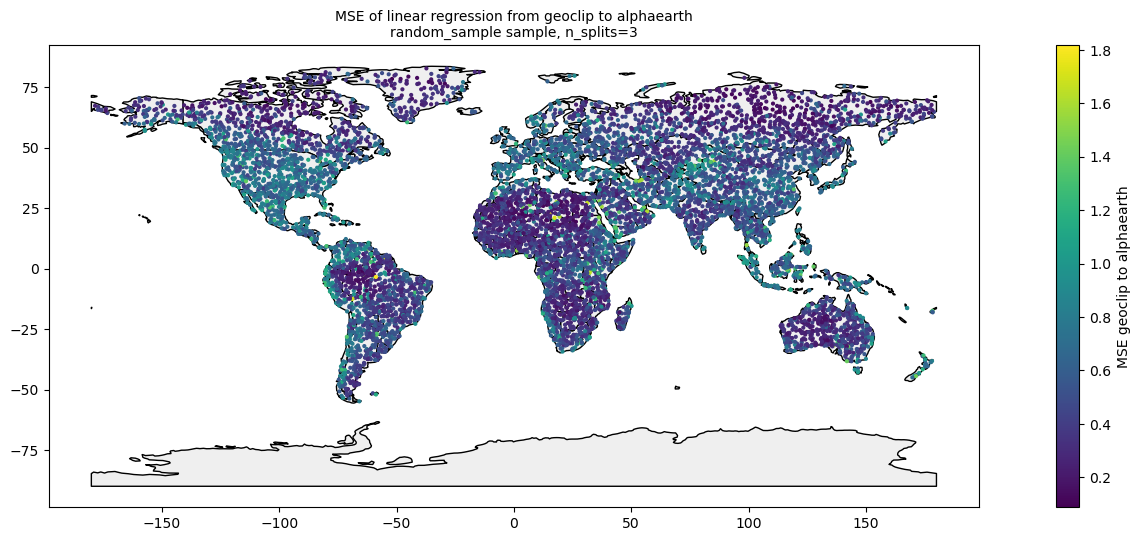

In [20]:
regressor = 'geoclip'
target = 'alphaearth'
sample_type = 'random_sample'

df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type=sample_type, zscore_embeddings=True) 
r2, mse, gdf_tmp, y_data = ou.get_r2_regression(df_all, col_names, regressor, target, n_splits=3)
gdf_tmp = gpd.GeoDataFrame(gdf_tmp, geometry=gpd.points_from_xy(gdf_tmp['lon'], gdf_tmp['lat']), crs='EPSG:4326')
fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_tmp.plot(column=f'{regressor}_to_{target}_mse', cmap='viridis', legend=True, markersize=4, ax=ax,
             legend_kwds={'label': f'MSE {regressor} to {target}'})
plt.title(f'MSE of linear regression from {regressor} to {target}\n{sample_type} sample, n_splits=3', fontsize=10)

In [21]:
target = 'alphaearth'
sample_type = 'random_sample'
list_regressors = ['geoclip', 'satclip', 'tessera', 'human_footprint', 'bioclim', 'dynamicworld', 'all_geospatial']
list_colors = ['#77AADD', '#EE8866', '#EEDD88', '#FFAABB', '#99DDFF', '#44BB99', '#BBCC33', '#AAAA00']
colors = {r: list_colors[ii] for ii, r in enumerate(list_regressors)}

results = {'dim_residual': [], 'dim_target': [], 'dim_predictions': [], 'regressor': [], 'target': [], 'r2': []}
# df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type=sample_type, zscore_embeddings=True)

for r in list_regressors:
    r2, mse, gdf_tmp, y_data = ou.get_r2_regression(df_all, col_names, r, target, n_splits=4, equalize_ambient_dim=False, regression_method='ridge', zscore_embeddings=True)
    results['regressor'].append(r)
    results['r2'].append(r2)
    results['target'].append(target)

    results['dim_residual'].append(ou.get_dim(y_data['residuals'])[0])
    results['dim_target'].append(ou.get_dim(y_data['target'])[0])
    results['dim_predictions'].append(ou.get_dim(y_data['predictions'])[0])

df_results_dim = pd.DataFrame(results)
df_results_dim = df_results_dim.sort_values('dim_predictions', ascending=False)
df_results_dim

,dim_residual,dim_target,dim_predictions,regressor,target,r2
2,40.073324,20.794031,12.907516,tessera,alphaearth,0.685541
0,34.071355,20.794031,10.569028,geoclip,alphaearth,0.497380
1,34.273438,20.794031,10.431632,satclip,alphaearth,0.490481
6,25.790266,20.794031,7.138645,all_geospatial,alphaearth,0.403082
4,25.948124,20.794031,4.950827,bioclim,alphaearth,0.297421
5,23.971415,20.794031,3.863545,dynamicworld,alphaearth,0.235614
3,21.608047,20.794031,1.250814,human_footprint,alphaearth,0.037982


Text(0.75, 1, 'Residual dim:')

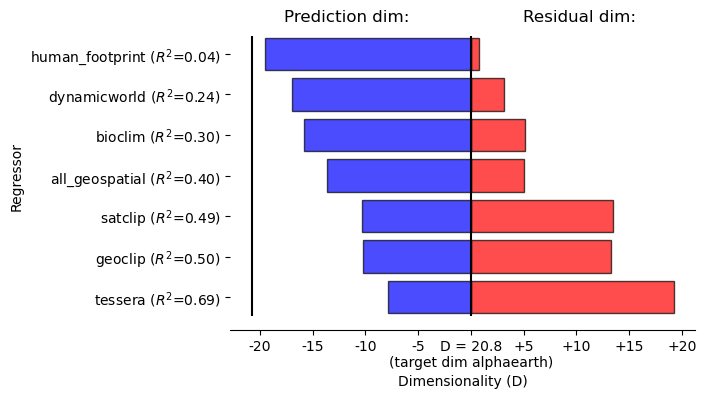

In [22]:

# heights = list(df_results_dim['dim_residual']) + [df_results_dim['dim_target'].iloc[0]] + list(df_results_dim['dim_predictions'])
# plt.bar(np.arange(len(heights)), heights)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(7)
target_dim = df_results_dim['dim_target'].iloc[0]
plt.barh(x, df_results_dim['dim_residual'] - target_dim , color='red', label='Residuals', alpha=0.7, edgecolor='black')
plt.barh(x, df_results_dim['dim_predictions'] - target_dim, color='blue', label='Predictions', alpha=0.7, edgecolor='black')

plt.vlines(0, -.45, 6.45, colors='black')
plt.vlines(-target_dim, -.45, 6.45, colors='black')

xticks = np.arange(-4, 5, 1) * 5
xticks_labels = list(xticks[:4]) + [f'D = {target_dim:.1f}\n(target dim {target})'] + [f'+{x}' for x in xticks[5:]]
ax.set_xticks(xticks)
ax.set_xticklabels(xticks_labels)
yticks = np.arange(len(df_results_dim))
ax.set_yticks(yticks)
yticklabels = [f"{row['regressor']} ($R^2$={row['r2']:.2f})" for _, row in df_results_dim.iterrows()]
ax.set_yticklabels(yticklabels)
for sp in ['top', 'right', 'left']:
    ax.spines[sp].set_visible(False)
ax.set_ylabel('Regressor')
ax.set_xlabel('Dimensionality (D)')
ax.annotate('Prediction dim:', xy=(0.25, 1), xycoords='axes fraction', ha='center', fontsize=12)
ax.annotate('Residual dim:', xy=(0.75, 1), xycoords='axes fraction', ha='center', fontsize=12)

In [23]:
df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type=sample_type, 
                                        zscore_embeddings=False) 

Sample random_sample has 10000 data points out of 18973.
Sample lc_stratified_sample has 10000 data points out of 18973.
alphaearth 9695
tessera 8901
satclip 10000
geoclip 10000
bioclim 9681
human_footprint 9681


Text(0.5, 1.0, 'alphaearth_emb_37\nlc_stratified_sample sample, n_splits=3')

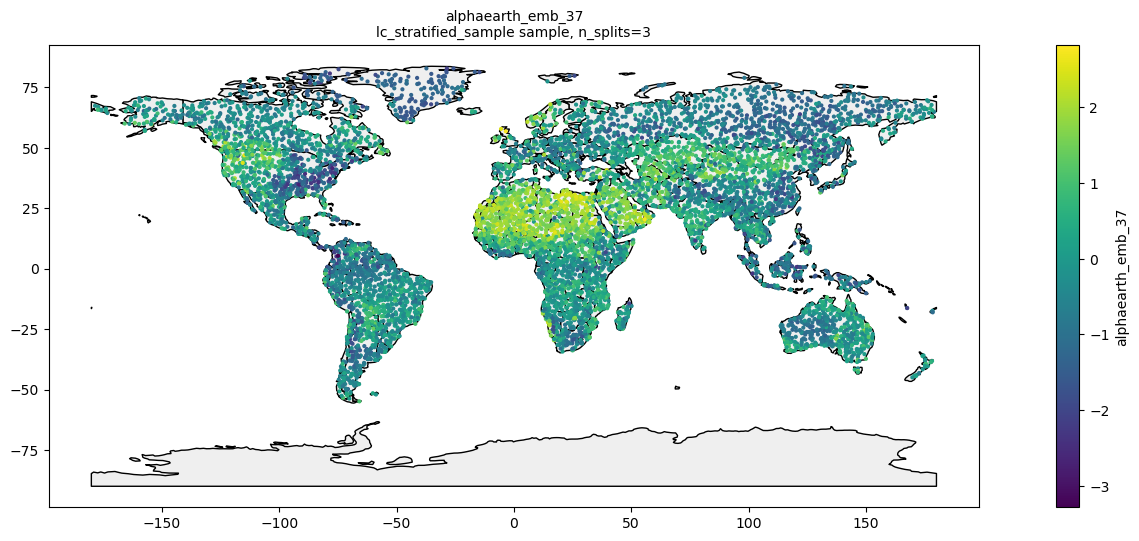

In [24]:
plot_mod = 'alphaearth_emb_37'
sample_type = 'lc_stratified_sample'

assert plot_mod in df_all.columns
gdf_tmp = gpd.GeoDataFrame(gdf_tmp, geometry=gpd.points_from_xy(gdf_tmp['lon'], gdf_tmp['lat']), crs='EPSG:4326')
fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_tmp.plot(column=plot_mod, cmap='viridis', legend=True, markersize=4, ax=ax,
             legend_kwds={'label': f'{plot_mod}'})
plt.title(f'{plot_mod}\n{sample_type} sample, n_splits=3', fontsize=10)

Sample random_sample has 10000 data points out of 18973.
Sample lc_stratified_sample has 10000 data points out of 18973.
alphaearth 9693
tessera 8829
satclip 10000
geoclip 10000
bioclim 9665
human_footprint 9665


Text(0.5, 1.0, 'Difference in MSE of linear regression between alphaearth and tessera\nlc_stratified_sample sample, n_splits=3, equal ambient dim: False')

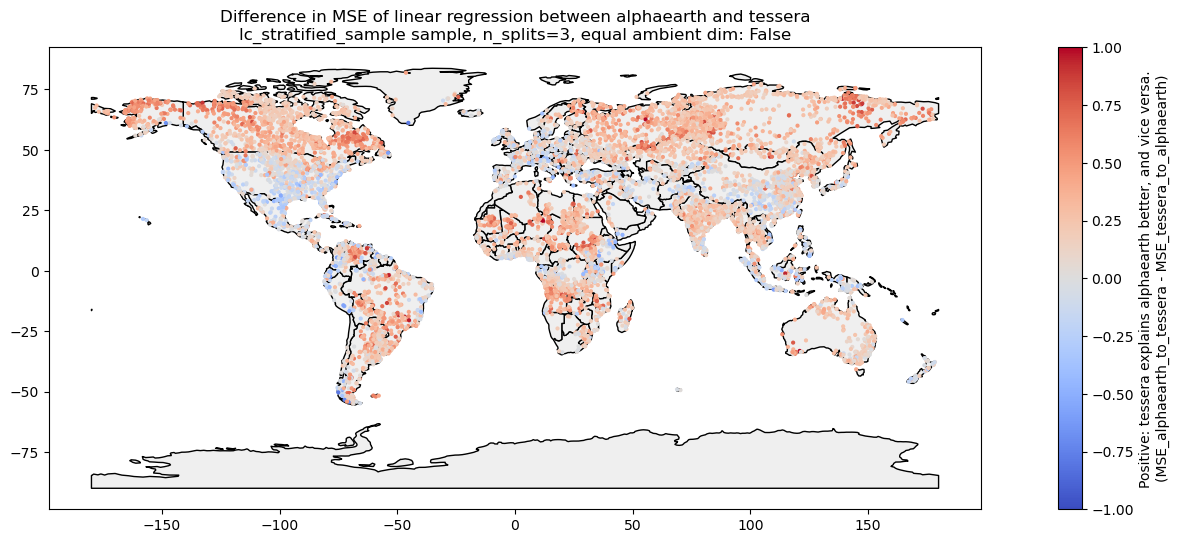

In [25]:
pair = ['alphaearth', 'tessera']
n_splits = 3
equalize_ambient_dim = False
sample_type = 'lc_stratified_sample'

df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type=sample_type, zscore_embeddings=True) 
_, __, gdf_1, ___ = ou.get_r2_regression(df_all, col_names, pair[0], pair[1], n_splits=n_splits, equalize_ambient_dim=equalize_ambient_dim,
                                            regression_method='ridge', zscore_embeddings=True)
gdf_1 = gpd.GeoDataFrame(gdf_1, geometry=gpd.points_from_xy(gdf_1['lon'], gdf_1['lat']), crs='EPSG:4326')
_, __, gdf_2, ___ = ou.get_r2_regression(df_all, col_names, pair[1], pair[0], n_splits=n_splits, equalize_ambient_dim=equalize_ambient_dim,
                                            regression_method='ridge', zscore_embeddings=True)
gdf_2 = gpd.GeoDataFrame(gdf_2, geometry=gpd.points_from_xy(gdf_2['lon'], gdf_2['lat']), crs='EPSG:4326')

## If positive, the 0->1 error is higher than the 1->0 error, and vice versa if negative.
## Hence, if positive, it means that 1 is better at predicting 0 than the other way around.
gdf_1[f'diff_mse_{pair[0]}_{pair[1]}'] = gdf_1[f'{pair[0]}_to_{pair[1]}_mse'] - gdf_2[f'{pair[1]}_to_{pair[0]}_mse']
# gdf_1['ae_dim'] = array_dim

# corr_dim_diff_mse = np.corrcoef(gdf_1['ae_dim'], gdf_1[f'diff_mse_{pair[0]}_{pair[1]}'])[0, 1]
# from scipy.stats import spearmanr
# corr_dim_diff_mse, pval = spearmanr(gdf_1['ae_dim'], gdf_1[f'diff_mse_{pair[0]}_{pair[1]}'])

fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
# lim = np.max(np.abs(gdf_1[f'diff_mse_{pair[0]}_{pair[1]}']))
gdf_1.plot(column=f'diff_mse_{pair[0]}_{pair[1]}', cmap='coolwarm', 
            legend=True, markersize=4, ax=ax, 
            # vmin=-lim, vmax=lim,
            vmin=-1, vmax=1,
            legend_kwds={'label': f'Positive: {pair[1]} explains {pair[0]} better, and vice versa.' +
            f'\n(MSE_{pair[0]}_to_{pair[1]} - MSE_{pair[1]}_to_{pair[0]})'})
plt.title(f'Difference in MSE of linear regression between {pair[0]} and {pair[1]}\n{sample_type} sample, n_splits={n_splits}, equal ambient dim: {equalize_ambient_dim}') #\n Spearman r diff MSE with AE dim: {corr_dim_diff_mse:.2f} (2-sided p-value: {pval:.2e})', fontsize=10)

## Next:
- Dim per AE/T patch, plot per point. Does any of the emb->emb performance correlate with dim (eg low dim in sahara)


In [ ]:
# list_ids, modality_folders, gdf_points = du.get_list_complete_ids(data_folder)
print(data_folder, sample_type)

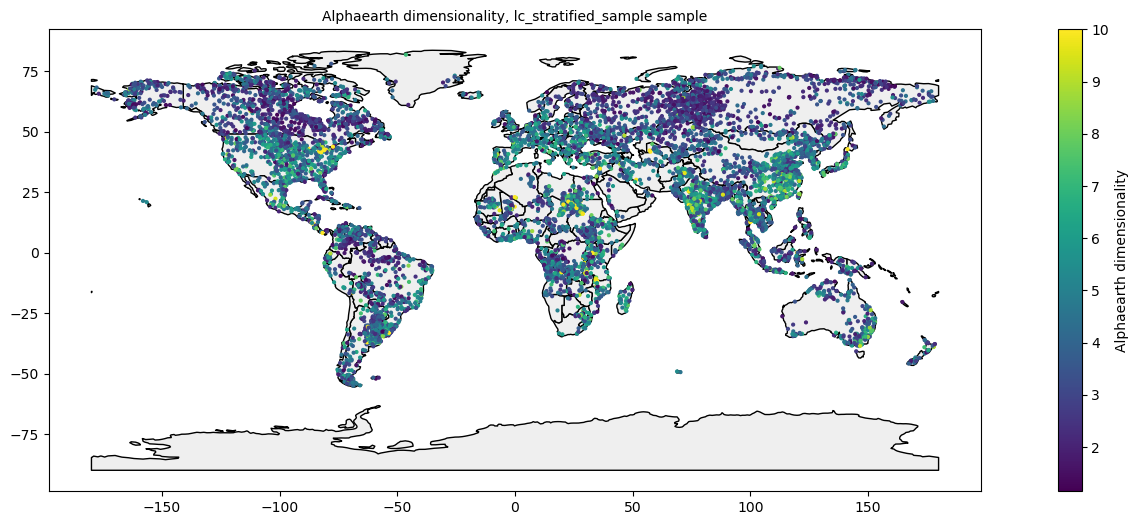

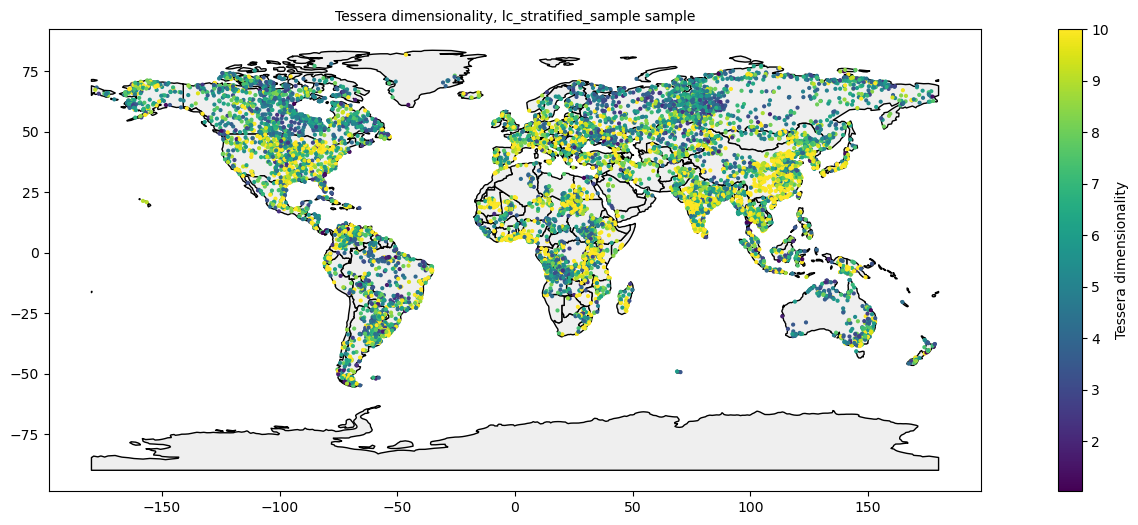

In [28]:

# df_dim = ou.get_list_dims(parent_folder=data_folder, sample_type=sample_type,
#                                     modality=model, save_results=True,
#                                     dir_save='../outputs/')
# array_dim = np.array([df_dim[df_dim['id'] == id_patch]['dim'].values[0] for id_patch in gdf_1.id])
for model in ['alphaearth', 'tessera']:
    df_dim = pd.read_csv(f'../outputs/{model}_dims_lc_stratified_sample.csv')
    array_dim = np.array([df_dim[df_dim['id'] == id_patch]['dim'].values[0] for id_patch in gdf_1.id])
    gdf_1[f'{model}_dim'] = array_dim
    gdf_1[f'{model}_dim_log'] = np.log(array_dim)
    gdf_1[f'{model}_dim'] = array_dim
    gdf_1[f'{model}_dim_log'] = np.log(array_dim)

    fig, ax = plt.subplots(figsize=(20,6))
    countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
    gdf_1.plot(column=f'{model}_dim', cmap='viridis', legend=True, markersize=4, ax=ax,
                legend_kwds={'label': f'{model.capitalize()} dimensionality'}, vmax=10)
    plt.title(f'{model.capitalize()} dimensionality, {sample_type} sample', fontsize=10)


In [29]:
# gdf_mse_plot
assert len(gdf_1) == len(gdf_mse_plot)
gdf_1 = gdf_1.sort_values('id')
gdf_mse_plot = gdf_mse_plot.sort_values('id')
assert (gdf_1['id'].values == gdf_mse_plot['id'].values).all(), "IDs in gdf_1 and gdf_mse_plot do not match after sorting, please check the IDs and sorting."

for c in gdf_mse_plot.columns[:4]:
    print(f'Adding column {c} to gdf_1')
    gdf_1[c] = gdf_mse_plot[c].values

n_rows_with_nans = gdf_1.isna().any(axis=1).sum()
print(f"Number of rows with NaN values: {n_rows_with_nans}")
## Remove rows with NaN values, if any:
if n_rows_with_nans > 0:
    gdf_1 = gdf_1.dropna()
    print(f"Dropped {n_rows_with_nans} rows with NaN values. New shape of gdf_1: {gdf_1.shape}")

gdf_2 = gdf_2[gdf_2['id'].isin(gdf_1['id'])]
assert (gdf_1['id'].values == gdf_2['id'].values).all(), "IDs in gdf_1 and gdf_2 do not match after filtering   gdf_2, please check the IDs and filtering."

gdf_1

Adding column mse__alphaearth__dynamicworld to gdf_1
Adding column mse__tessera__dynamicworld to gdf_1
Adding column mse__alphaearth_tessera__dynamicworld to gdf_1
Adding column compl__alphaearth_tessera__dynamicworld to gdf_1
Number of rows with NaN values: 3
Dropped 3 rows with NaN values. New shape of gdf_1: (8826, 1006)


,id,lat,lon,water,trees,grass,flooded_vegetation,crops,shrub_and_scrub,built,...,geometry,diff_mse_alphaearth_tessera,alphaearth_dim,alphaearth_dim_log,tessera_dim,tessera_dim_log,mse__alphaearth__dynamicworld,mse__tessera__dynamicworld,mse__alphaearth_tessera__dynamicworld,compl__alphaearth_tessera__dynamicworld
0,14,63.157235,-108.571958,0.224916,0.078407,0.064286,0.051383,0.036877,0.065301,0.037161,...,POINT (-108.57196 63.15723),0.333262,1.688892,0.524073,4.359550,1.472369,0.223344,0.185978,0.208194,0.067834
1,27,28.987267,31.013628,0.030171,0.031852,0.021780,0.030876,0.056204,0.132950,0.546845,...,POINT (31.01363 28.98727),-0.000495,2.021618,0.703898,3.915172,1.364859,0.199664,0.132581,0.090209,0.548196
2,43,37.348867,126.746009,0.201682,0.036917,0.040571,0.044532,0.049349,0.048390,0.446932,...,POINT (126.74601 37.34887),0.367925,4.430425,1.488495,8.723597,2.166032,0.530478,0.448375,0.427634,0.193870
3,45,20.080457,78.056067,0.064011,0.167659,0.074418,0.065935,0.376648,0.106467,0.045721,...,POINT (78.05607 20.08046),0.281912,4.093538,1.409410,10.067727,2.309335,0.127238,0.057668,0.067063,0.472936
4,74,20.274966,-2.382564,0.027500,0.026078,0.022544,0.025856,0.048545,0.074745,0.042490,...,POINT (-2.38256 20.27497),0.370741,5.545309,1.712952,7.177674,1.970975,0.012780,0.109641,0.033314,-1.606658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8824,99932,38.147586,126.925923,0.033408,0.318447,0.126851,0.052028,0.080486,0.153592,0.033376,...,POINT (126.92592 38.14759),0.171146,4.915750,1.592444,9.596953,2.261446,0.618357,0.061652,0.267480,0.567434
8825,99941,45.952213,9.280576,0.736304,0.044034,0.025686,0.047263,0.028354,0.030455,0.021818,...,POINT (9.28058 45.95221),0.378397,1.717561,0.540905,3.182182,1.157567,0.070739,0.026890,0.055482,0.215681
8826,99947,18.541070,27.903852,0.030774,0.022880,0.022553,0.024440,0.064815,0.065988,0.046802,...,POINT (27.90385 18.54107),0.101879,4.070244,1.403703,13.060314,2.569578,0.024609,0.017915,0.028084,-0.141187
8827,99962,55.538803,-68.456589,0.035856,0.103534,0.152562,0.076544,0.031508,0.264419,0.032408,...,POINT (-68.45659 55.5388),0.601263,3.725731,1.315263,7.566922,2.023786,0.375503,0.361245,0.295412,0.213289


In [30]:
dict_corrs = {x: [] for x in ['col_name', 'spearmanr_corr', 'spearmanr_pval']}
for c in gdf_1.columns:
    try:
        corr, pval = spearmanr(gdf_1[c], gdf_1['compl__alphaearth_tessera__dynamicworld'])
    except:
        print(f"Could not compute correlation for column {c}, skipping.")
        continue
    dict_corrs['col_name'].append(c)
    dict_corrs['spearmanr_corr'].append(corr)
    dict_corrs['spearmanr_pval'].append(pval)

df_corrs = pd.DataFrame(dict_corrs)
df_corrs = df_corrs.sort_values('spearmanr_corr', key=lambda x: np.abs(x), ascending=False)
print(df_corrs.head(20))


Could not compute correlation for column geometry, skipping.
                                     col_name  spearmanr_corr  spearmanr_pval
1004  compl__alphaearth_tessera__dynamicworld        1.000000    0.000000e+00
1001            mse__alphaearth__dynamicworld        0.282987   3.458661e-162
1002               mse__tessera__dynamicworld       -0.252857   8.393098e-129
1003    mse__alphaearth_tessera__dynamicworld       -0.232622   9.206578e-109
49                          alphaearth_emb_37       -0.113673    8.894567e-27
985                                bioclim_14        0.105385    3.183173e-23
988                                bioclim_17        0.102002    7.511301e-22
199                           tessera_emb_123       -0.097597    3.945429e-20
143                            tessera_emb_67        0.097402    4.680405e-20
788                           geoclip_emb_328        0.097378    4.778916e-20
981                                bioclim_10       -0.096740    8.354764e-20
10 

In [31]:
tmp_ae = np.array(final_dict_r2_per_split[('alphaearth', 'dynamicworld')])
tmp_te = np.array(final_dict_r2_per_split[('tessera', 'dynamicworld')])
tmp_ae_te = np.array(final_dict_r2_per_split[('alphaearth_tessera', 'dynamicworld')])

c_ae_te = (tmp_ae_te - tmp_ae) / (1 - tmp_ae)
c_ae_te_mean = (tmp_ae_te.mean() - tmp_ae.mean()) / (1 - tmp_ae.mean())

print(f'Complementarity of alphaearth and tessera for dynamicworld regression: {c_ae_te_mean} (mean across splits), with values per split: {c_ae_te.mean()}')
spearmanr(c_ae_te, tmp_ae)

Complementarity of alphaearth and tessera for dynamicworld regression: 0.1913635850840415 (mean across splits), with values per split: 0.19153811388246314


SignificanceResult(statistic=np.float64(0.24511278195488717), pvalue=np.float64(0.2976005003886618))